label
ham     8500
spam    1500
Name: count, dtype: int64
label
ham     0.85
spam    0.15
Name: proportion, dtype: float64


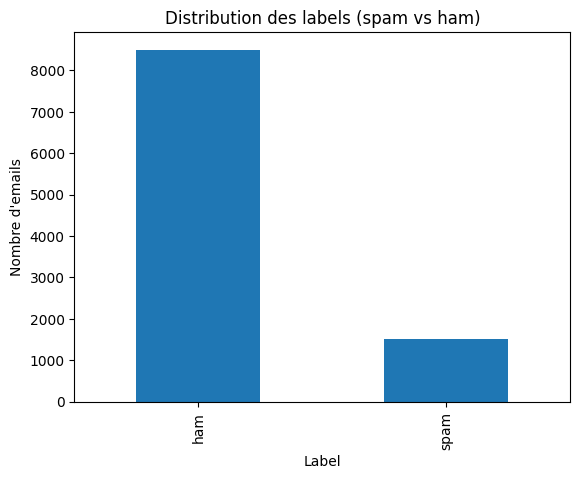

Before SMOTE:
 label
ham     6800
spam    1200
Name: count, dtype: int64

After SMOTE:
 label
ham     6800
spam    6800
Name: count, dtype: int64

Classification Report:

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00      1700
        spam       1.00      1.00      1.00       300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



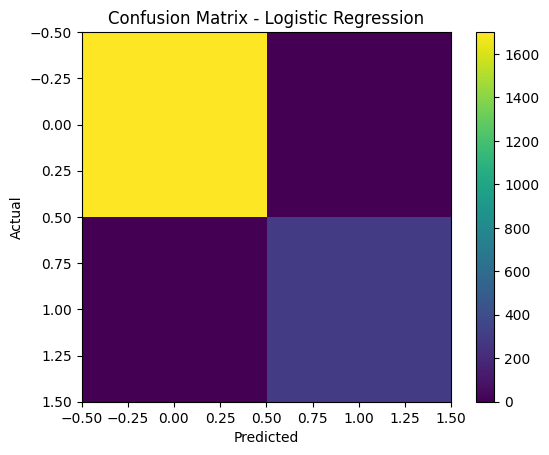

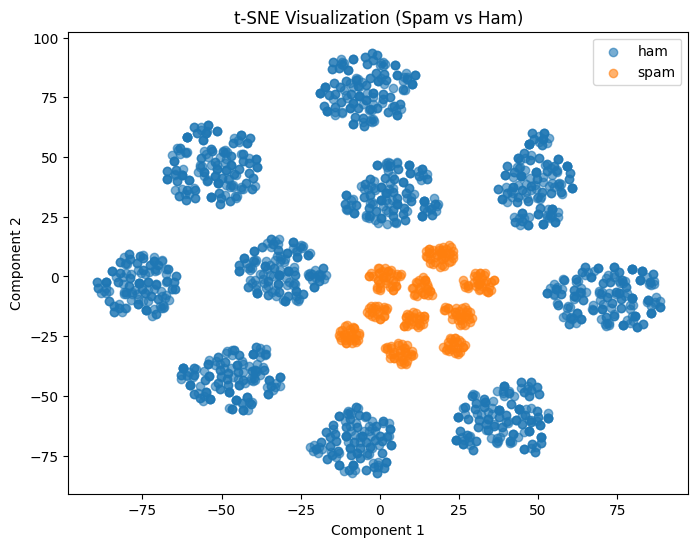

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE

# ==============================
# 1. Load dataset
# ==============================
df = pd.read_csv("/work/20260408-141321/email_classification_dataset.csv")
# Charger le datasetdf = pd.read_csv("/work/20260408-141321/email_classification_dataset.csv")

# Aperçu des données
df.head()

# Distribution des labels
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

# Visualisation
df["label"].value_counts().plot(kind="bar")
plt.title("Distribution des labels (spam vs ham)")
plt.xlabel("Label")
plt.ylabel("Nombre d'emails")
plt.show()
# ==============================
# 2. Features / Target
# ==============================
X = df["email"]
y = df["label"]

# ==============================
# 3. Train / Test split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 4. TF-IDF vectorization
# ==============================
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ==============================
# 5. Oversampling (SMOTE)
# ==============================
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_res).value_counts())

# ==============================
# 6. Logistic Regression Model
# ==============================
model = LogisticRegression(max_iter=1000)

model.fit(X_train_res, y_train_res)

# ==============================
# 7. Prediction
# ==============================
y_pred = model.predict(X_test_tfidf)

# ==============================
# 8. Evaluation
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# ==============================
# 9. t-SNE Visualization
# ==============================
sample_size = 2000

X_sample = X_test_tfidf[:sample_size].toarray()
y_sample = y_test[:sample_size].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8,6))

for label in np.unique(y_sample):
    idx = y_sample == label
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Visualization (Spam vs Ham)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()